In [ ]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

ARQUIVO = "/base_de_dados_imoveis-classificação.xlsx"
df = pd.read_excel(ARQUIVO)

print("Colunas disponíveis:")
print(df.columns)

print("\nPrimeiras linhas:")
print(df.head())

Colunas disponíveis:
Index(['renda_media', 'media_quartos', 'populacao', 'latitude', 'longitude',
       'idade_media_casas', 'categoria_preco'],
      dtype='object')

Primeiras linhas:
   renda_media  media_quartos  populacao  latitude  longitude  \
0          3.2            4.5       1200     34.05    -118.24   
1          8.5            6.8        850     37.77    -122.42   
2          5.1            5.2       2300     36.77    -119.41   
3          2.8            4.0       3100     35.37    -119.02   
4          9.3            7.5        600     37.80    -122.27   

   idade_media_casas categoria_preco  
0                 25           Baixo  
1                 15            Alto  
2                 30           Médio  
3                 40           Baixo  
4                 10            Alto  


In [ ]:
FEATURES = ["renda_media",
            "populacao",
            "latitude"]

TARGET = "categoria_preco"            # coluna F (classe)

for col in FEATURES :
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Normaliza o target e remove linhas inválidas
df[TARGET] = df[TARGET].astype(str).str.strip().str.lower()
df = df.dropna(subset=FEATURES + [TARGET]).copy() #remove linhas com valores inválidos

print("\nDistribuição do target:")
print(df[TARGET].value_counts())


Distribuição do target:
categoria_preco
baixo    17
alto     17
médio    16
Name: count, dtype: int64


In [ ]:
le = LabelEncoder()
y_all = le.fit_transform(df[TARGET])
X_all = df[FEATURES].values

print("\nClasses:", list(le.classes_))
print("Total linhas válidas:", len(df))


Classes: ['alto', 'baixo', 'médio']
Total linhas válidas: 50


In [ ]:
RANDOM_STATE = 42
df_shuffled = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
limite_teste=int(len(df)*0.20) # Split : 20% teste + 80% treino
test_df  = df_shuffled.iloc[:limite_teste].copy()
train_df = df_shuffled.iloc[limite_teste:len(df)].copy()
X_train = train_df[FEATURES].values
y_train = le.transform(train_df[TARGET])
X_test  = test_df[FEATURES].values
y_test  = le.transform(test_df[TARGET])
print("\nTreino:", len(train_df), "| Teste:", len(test_df))


Treino: 40 | Teste: 10


In [ ]:
def dist_classes(frame, target_col, titulo):
    vc = frame[target_col].value_counts(dropna=False)
    pct = (vc / len(frame) * 100).round(1)
    out = pd.DataFrame({"qtd": vc, "%": pct})
    print(f"\n=== {titulo} (n={len(frame)}) ===")
    display(out)

dist_classes(df, TARGET, "Dataset completo")
dist_classes(train_df, TARGET, "Treino")
dist_classes(test_df, TARGET, "Teste")


=== Dataset completo (n=50) ===


,qtd,%
categoria_preco,,
baixo,17,34.0
alto,17,34.0
médio,16,32.0



=== Treino (n=40) ===


,qtd,%
categoria_preco,,
alto,14,35.0
baixo,13,32.5
médio,13,32.5



=== Teste (n=10) ===


,qtd,%
categoria_preco,,
baixo,4,40.0
alto,3,30.0
médio,3,30.0


In [ ]:
# Modelo KNN
K = 5
WEIGHTS = "distance"  # "uniform" ou "distance"

model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=K, weights=WEIGHTS))
])

model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('knn', KNeighborsClassifier(weights='distance'))])

In [ ]:
# Avaliação

y_pred = model.predict(X_test)

print("\nFeatures usadas:", FEATURES)
print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nRelatório:")
print(classification_report(y_test, y_pred, target_names=le.classes_))
print("Matriz de confusão (real x previsto):")
print(confusion_matrix(y_test, y_pred))



Features usadas: ['renda_media', 'populacao', 'latitude']
Acurácia: 1.0

Relatório:
              precision    recall  f1-score   support

        alto       1.00      1.00      1.00         3
       baixo       1.00      1.00      1.00         4
       médio       1.00      1.00      1.00         3

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10

Matriz de confusão (real x previsto):
[[3 0 0]
 [0 4 0]
 [0 0 3]]


In [ ]:
# Resultado detalhado do teste

test_df["classe_prevista"] = le.inverse_transform(y_pred)

display(test_df[FEATURES + [TARGET, "classe_prevista"]])

,renda_media,populacao,latitude,categoria_preco,classe_prevista
0,9.8,500,37.87,alto,alto
1,2.6,3400,35.25,baixo,baixo
2,3.1,3000,34.75,baixo,baixo
3,2.1,4100,35.70,baixo,baixo
4,4.9,2500,36.33,médio,médio
5,3.4,2750,34.85,baixo,baixo
6,4.2,2600,38.20,médio,médio
7,7.6,980,37.60,alto,alto
8,6.2,1750,34.05,médio,médio
9,8.2,780,37.55,alto,alto



=== Árvore de decisão ===
Features usadas: ['renda_media', 'populacao', 'latitude']
Acurácia: 1.0

Relatório:
              precision    recall  f1-score   support

        alto       1.00      1.00      1.00         3
       baixo       1.00      1.00      1.00         4
       médio       1.00      1.00      1.00         3

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10

Matriz de confusão (real x previsto):
[[3 0 0]
 [0 4 0]
 [0 0 3]]


,renda_media,populacao,latitude,categoria_preco,classe_prevista_arvore
0,9.8,500,37.87,alto,alto
1,2.6,3400,35.25,baixo,baixo
2,3.1,3000,34.75,baixo,baixo
3,2.1,4100,35.70,baixo,baixo
4,4.9,2500,36.33,médio,médio
5,3.4,2750,34.85,baixo,baixo
6,4.2,2600,38.20,médio,médio
7,7.6,980,37.60,alto,alto
8,6.2,1750,34.05,médio,médio
9,8.2,780,37.55,alto,alto


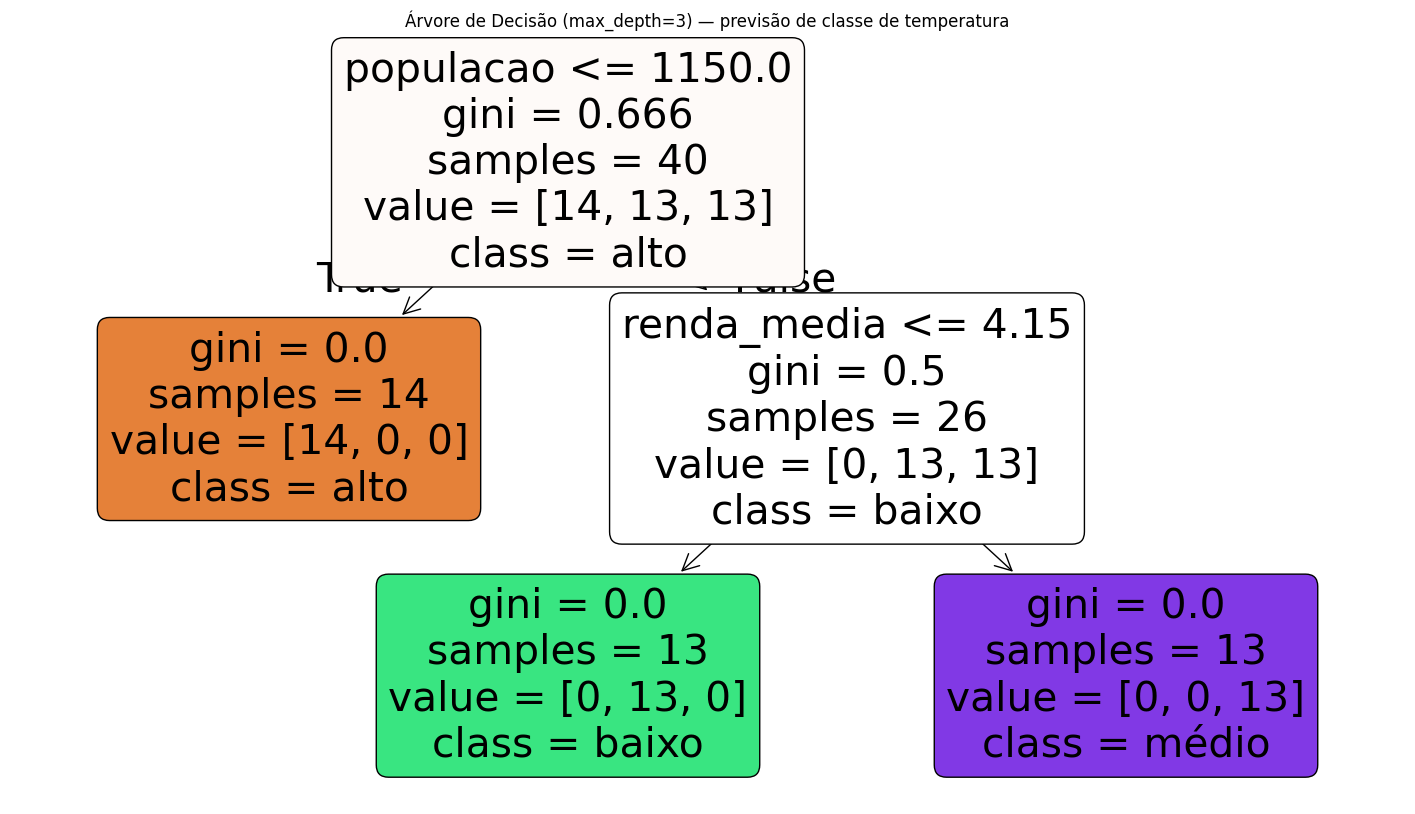

In [ ]:
# ========= Árvore de decisão (usando as MESMAS variáveis do seu Colab) =========
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# "simples" e legível para aula (ajuste se quiser):
tree = DecisionTreeClassifier(
    max_depth=3,          # controla complexidade/legibilidade
    random_state=RANDOM_STATE
)

tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

print("\n=== Árvore de decisão ===")
print("Features usadas:", FEATURES)
print("Acurácia:", accuracy_score(y_test, y_pred_tree))
print("\nRelatório:")
print(classification_report(y_test, y_pred_tree, target_names=le.classes_))
print("Matriz de confusão (real x previsto):")
print(confusion_matrix(y_test, y_pred_tree))

# Resultado detalhado do teste (sem mudar sua tabela do KNN, usa outra coluna)
test_df["classe_prevista_arvore"] = le.inverse_transform(y_pred_tree)
display(test_df[FEATURES + [TARGET, "classe_prevista_arvore"]])

# desenhar a árvore
plt.figure(figsize=(18, 10))
plot_tree(
    tree,
    feature_names=FEATURES,
    class_names=list(le.classes_),
    filled=True,
    rounded=True,
    impurity=True
)
plt.title("Árvore de Decisão (max_depth=3) — previsão de classe de temperatura")
plt.show()